##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
# Load the images


# Predict classes


In [59]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
import keras_hub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [60]:
# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preset = "vit_base_patch16_224_imagenet"
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(preset)

In [61]:
# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
model = keras_hub.models.ViTImageClassifier.from_preset(
    preset,
    preprocessor=None
)

In [62]:
# Load the images
labels_path = keras.utils.get_file(
    "ImageNetLabels.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt"
)

with open(labels_path, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

if len(class_names) == 1001:
    class_names = class_names[1:]

In [63]:
image_info = [
    {
        "file_name": "banana.jpg",
        "path": "/content/drive/MyDrive/Lab 3/images/banana.jpg",
        "true_label": "banana"
    },
    {
        "file_name": "cat.jpg",
        "path": "/content/drive/MyDrive/Lab 3/images/cat.jpg",
        "true_label": "tabby cat"
    },
    {
        "file_name": "goldfish.jpg",
        "path": "/content/drive/MyDrive/Lab 3/images/goldfish.jpg",
        "true_label": "goldfish"
    },
    {
        "file_name": "bus.jpg",
        "path": "/content/drive/MyDrive/Lab 3/images/bus.jpg",
        "true_label": "school bus"
    },
    {
        "file_name": "daisy.jpg",
        "path": "/content/drive/MyDrive/Lab 3/images/daisy.jpg",
        "true_label": "daisy"
    }
]

In [64]:
for item in image_info:
    print(item["path"], os.path.exists(item["path"]))

/content/drive/MyDrive/Lab 3/images/banana.jpg True
/content/drive/MyDrive/Lab 3/images/cat.jpg True
/content/drive/MyDrive/Lab 3/images/goldfish.jpg True
/content/drive/MyDrive/Lab 3/images/bus.jpg True
/content/drive/MyDrive/Lab 3/images/daisy.jpg True


In [65]:
# Predict classes
results = []

for item in image_info:
    image = keras.utils.load_img(item["path"])
    image_array = keras.utils.img_to_array(image)
    image_batch = tf.expand_dims(image_array, axis=0)

    processed = preprocessor(image_batch)
    logits = model.predict(processed, verbose=0)

    pred_index = int(np.argmax(logits[0]))
    predicted_label = class_names[pred_index]

    predicted_label_lower = predicted_label.lower()
    true_label_lower = item["true_label"].lower()

    correct = "Yes" if true_label_lower in predicted_label_lower or predicted_label_lower in true_label_lower else "No"

    results.append({
        "Image File": item["file_name"],
        "Predicted Label": predicted_label,
        "True Label": item["true_label"],
        "Correct?": correct
    })

In [66]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

  Image File Predicted Label True Label Correct?
  banana.jpg          banana     banana      Yes
     cat.jpg           tabby  tabby cat      Yes
goldfish.jpg        goldfish   goldfish      Yes
     bus.jpg      school bus school bus      Yes
   daisy.jpg           daisy      daisy      Yes


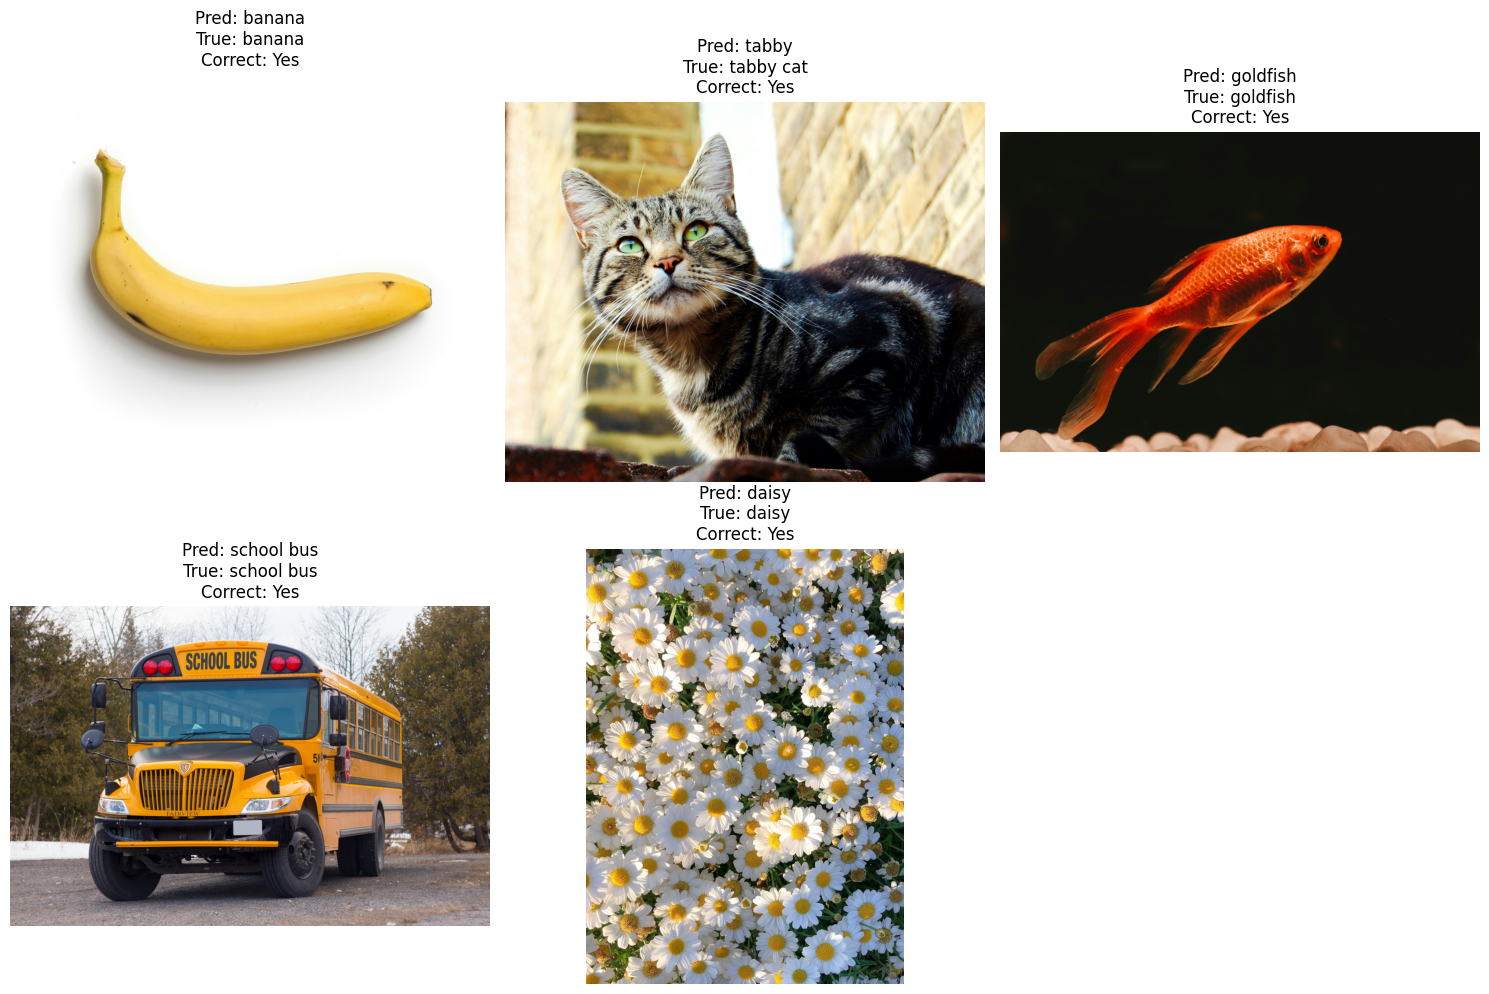

In [67]:
plt.figure(figsize=(15, 10))
for i, item in enumerate(image_info):
    img = keras.utils.load_img(item["path"])
    row = results[i]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {row['Predicted Label']}\nTrue: {row['True Label']}\nCorrect: {row['Correct?']}")
    plt.axis("off")

plt.tight_layout()
plt.show()